## 1. Chargement de la base de données

Dans cette section, nous importons la base nettoyée `Base1Base2_clean`.  
Cette base regroupe les réponses issues des deux vagues (E1 et E2) après filtrage initial
et préparation préalable.  
L’objectif est de présenter ici les premières statistiques descriptives avant la phase de
modélisation thématique.

#### Imports supplémentaires nécessaires pour les visualisations descriptives

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# !pip install wordcloud # Décommentez cette ligne si le package wordcloud n'est pas encore installé
from wordcloud import WordCloud
import spacy
from sklearn.feature_extraction.text import CountVectorizer
from collections import defaultdict

df = pd.read_csv('Base1Base2_clean', sep = ',')

### Données Descriptives

Cette section présente la distribution des variables sociodémographiques
(genre, âge) et des diagnostics déclarés.  
Ces éléments permettent de contextualiser ensuite l’analyse thématique.

#### Vérification rapide des colonnes

Nous affichons les noms des colonnes pour repérer les variables utiles
(aux diagnostics notamment) et vérifier que le jeu de données a été correctement chargé.

In [ ]:
# Liste des colonnes disponibles dans la base

df.columns

Index(['ID de la réponse', 'Genre', 'Genre [Autre]', 'Age',
       'Quel est votre niveau d'étude ? ', 'Activité Professionnelle - Autre',
       'Merci de nous indiquez ici le ou les trouble(s) psychiatriques (e.g. dépression) dont vous souffrez actuellement (si vous ne souffrez pas de trouble psychiatrique, passez à la question suivante)',
       'Ce(s) trouble(s) ont-il été diagnostiqué(s) par un psychiatre?',
       'Merci d'indiquer ici le ou les troubles psychiatriques dont vous avez pu souffrir par le passé (si vous n'avez pas d'antécédent de trouble psychiatrique, passez à la question suivante)',
       'Psychothérapie - Autre',
       'Au quotidien, quelles sont les pensées (ex : « Je suis nul(le) ») qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ? ',
       'Au quotidien, quelles sont les émotions (ex : tristesse ») qui peuvent éventuellement vous faire souffrir, pouvez-vous nous les expliquer ? ',
       'Au quotidien, quels sont les comportem

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

## 2. Répartition par genre

Nous examinons ici la distribution des réponses selon le genre.  

#### Comptage brut des réponses par genre

In [ ]:
### Comptage brut des réponses par genre

df.Genre.value_counts()

Genre
Femme                       335
Homme                       123
Autre                         8
Ne souhaite pas répondre      1
Name: count, dtype: int64

#### Nettoyage des valeurs manquantes / refus de répondre

Nous retirons les réponses "Ne souhaite pas répondre" afin de présenter
des distributions plus pertinentes.

C:\Users\kazzi\AppData\Local\Temp\ipykernel_14108\1460907462.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


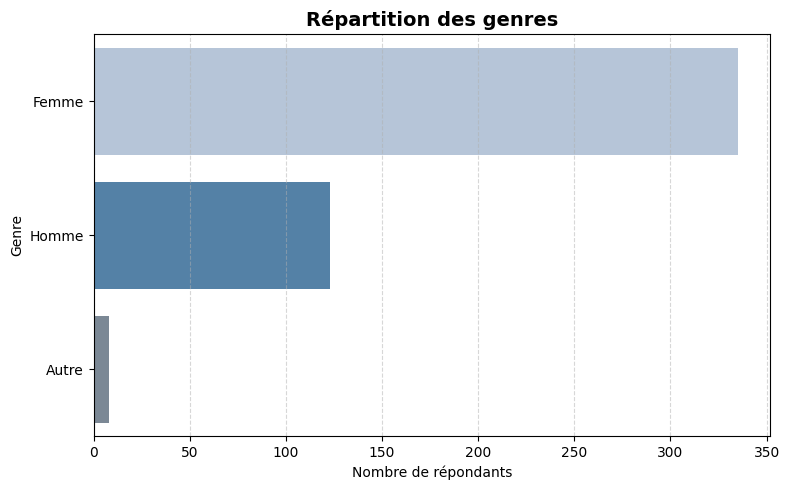

In [ ]:
# Supprimer les réponses "Ne souhaite pas répondre"
df_filtré = df[df['Genre'] != 'Ne souhaite pas répondre']

# Définir des couleurs personnalisées adaptées à la slide (bleu lavande, bleu foncé, gris)
couleurs = {
    'Femme': '#b0c4de',  # lavande bleutée
    'Homme': '#4682b4',  # bleu acier foncé
    'Autre': '#778899'   # gris bleuté
}

# Compter les occurrences manuellement pour avoir l'ordre et palette
genre_counts = df_filtré['Genre'].value_counts()
ordres = genre_counts.index.tolist()
couleur_personnalisee = [couleurs.get(genre, '#999999') for genre in ordres]

# Plot genre
plt.figure(figsize=(8,5))
sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index,
    palette=couleur_personnalisee
)
plt.title("Répartition des genres", fontsize=14, fontweight='bold')
plt.xlabel("Nombre de répondants")
plt.ylabel("Genre")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 3. Répartition par âge

Nous visualisons ici la distribution des âges des participants.  
Cette information est utile pour contextualiser les réponses qualitatives,
certaines thématiques pouvant varier selon la tranche d'âge.

#### Distribution de l’âge (histogramme)

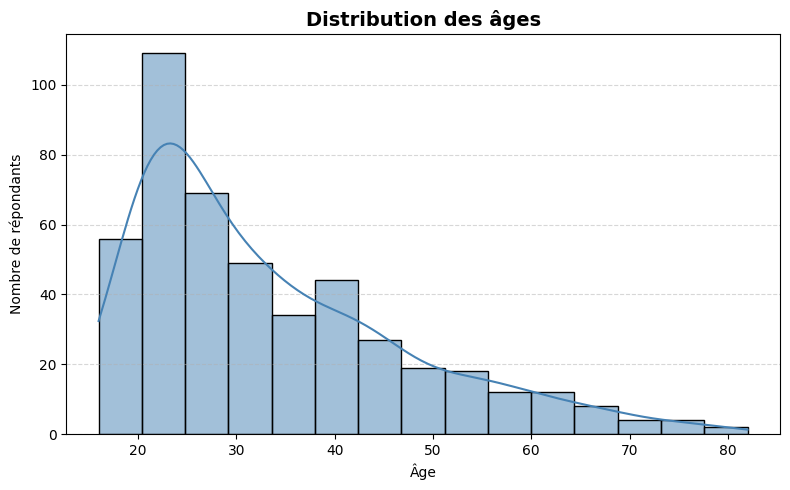

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='Age',
    bins=15,
    kde=True, # estimation de densité pour lisibilité
    color="#4682b4", 
    edgecolor='black'
)
plt.title("### Distribution de l’âge (histogramme)", fontsize=14, fontweight='bold')
plt.xlabel("Âge")
plt.ylabel("Nombre de répondants")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Diagnostics principaux

Nous identifions ici les colonnes contenant les diagnostics déclarés par les participants.  
Ces variables serviront plus tard dans l'analyse croisée avec les topics via BERTopic.

#### Identification des colonnes associées aux diagnostics psychiatriques

In [ ]:
# On repère les colonnes contenant les diagnostics en cherchant les chaînes "psychiatriques" ou "Diagnostic"
col_diag = [
    col for col in df.columns
    if 'psychiatriques' in col or 'Diagnostic' in col
]

# Exemple de colonne sélectionnée
col_diag[2]

'Diagnostic_mots_cles'

#### Fusion des colonnes liées aux diagnostics

Dans le questionnaire, plusieurs colonnes peuvent contenir des informations
liées aux diagnostics psychiatriques.  
Nous les regroupons ici dans une variable unique afin de simplifier les analyses
descriptives et les croisements ultérieurs avec les topics.

Cette étape est essentielle pour éviter les doublons ou incohérences lors de l'interprétation clinique.

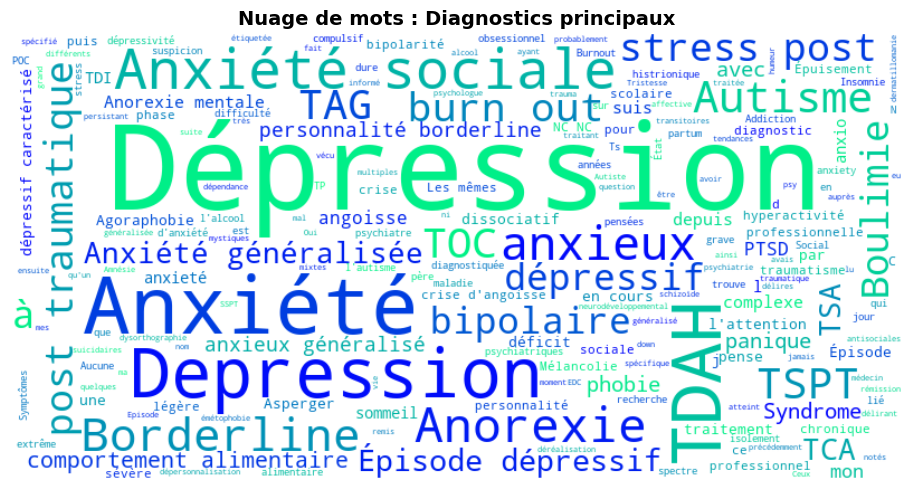

In [ ]:
# Fusion des colonnes contenant les diagnostics
# diagnostic_cols = [
#     'Merci de nous indiquer ici les trouble(s) psychiatriques [...]',
#     'Ce(s) trouble(s) ont-il été diagnostiqué(s) par un psychiatre?',
#     'Merci d’indiquer ici les troubles psychiatriques [...] passé',
#     'Diagnostic_mots_cles'
# ]

# Concaténation des textes
diagnostics_text = df[col_diag].astype(str).apply(lambda x: ' '.join(x), axis=1).str.cat(sep=' ')

# Liste de mots à exclure (non pertinents)
stopwords_personnalises = set([
    'nan', 'Aucun', 'aucun', 'autre', 'Autre', 'non', 'Non', 'je', 'Je', 'et', 'de', 'du', 'des', 'la', 'le', 'un',
    'diagnostiqué', 'diagnostique', 'souffre', 'souffert', 'souffrir', 'actuellement', 'passé', 'troubles', 'trouble',
    'pas', 'si', 'avez', 'vous', "n'ai", 'ai', 'été', 'ne', 'souhaite', 'répondre', 'présent', 'présents', "mais", "me", "ans", "encore", "a", "etre", "ou", "sans", "voir", "type"
])

# Génération du nuage de mots avec couleurs harmonisées
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='winter',  # Colormap bleu-vert doux pour cohérence
    stopwords=stopwords_personnalises
).generate(diagnostics_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Nuage de mots : Diagnostics principaux", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


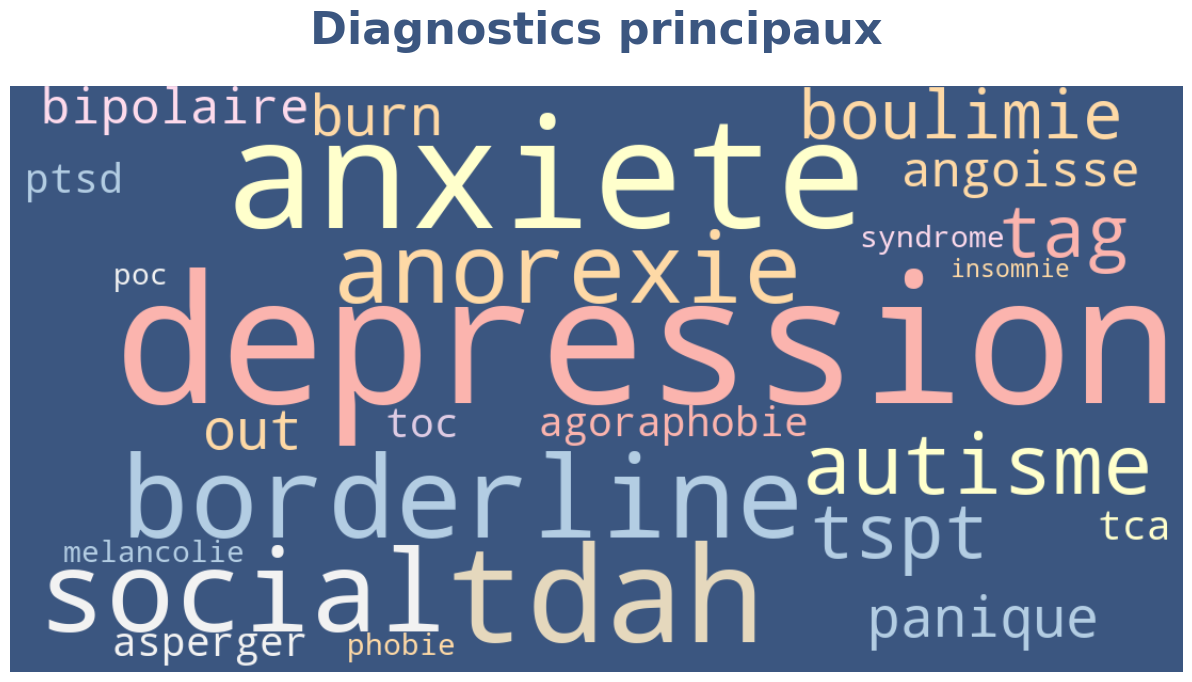

In [ ]:
# Modèle spaCy FR
nlp = spacy.load("fr_core_news_sm")

# PARAMÈTRES
ngram_min = 1
ngram_max = 2
colonnes_a_utiliser = ["Diagnostic_mots_cles"] 
max_words = 80
min_freq = 2
wordcloud_seed = 25
colormap_choice = 'Pastel1'  # palette douce et harmonieuse



import re

# Avant tout le traitement, dans ton texte d'origine :
EXPRESSION_FIXES = {
    "burn out": "burn_out",
    "burnout": "burn_out",  # tu peux en ajouter d'autres, ex: "trouble bipolaire": "trouble_bipolaire"
    # "trouble bipolaire": "trouble_bipolaire",
    # "stress post traumatique": "stress_post_traumatique",
    # etc.
}

diagnostics_text = df[colonnes_a_utiliser].astype(str).apply(lambda row: ' '.join(row.values), axis=1).str.cat(sep=' ')

# Remplacement avant le passage à spaCy :
for mot, repl in EXPRESSION_FIXES.items():
    diagnostics_text = re.sub(rf'\b{mot}\b', repl, diagnostics_text, flags=re.IGNORECASE)

# Puis tu fais le traitement spaCy, lemmatisation etc. comme avant

doc = nlp(diagnostics_text)
lemmas = [
    token.lemma_.lower().replace("burn_out", "Burn out")  # tu peux remettre l'espace pour l'affichage
    if token.text.lower() == "burn_out" else token.lemma_.lower()
    for token in doc if not token.is_punct and not token.is_space and not token.is_stop
]


# STOPWORDS personnalisés (complétés)
stopwords_personnalises = [
    'nan', 'aucun', 'autre', 'non', 'je', 'et', 'de', 'du', 'des', 'la', 'le', 'un',
    'diagnostiquer', 'souffrir', 'actuellement', 'passer', 'présent', 'pas', 'si', 'avoir', 'vous', 'être', 'ne', 'souhaiter', 'répondre',
    'diagnostic', 'psychiatrique', 'trouble', 'symptome', 'symptomatique', 'etat', 'mental', 'professionnel', 'professionnelle', 'psychologue', 'psychiatre', 'maladie',
    'traitement', 'traiter', 'soin', 'prise', 'charge', 'consultation', 'suivi', 'type', 'niveau', 'difficulte', 'situation', 'relation',
    'souhait', 'reponse', 'mot', 'cle', 'cause', 'consequence', 'probleme', 'doute', 'sentiment', 'pensée', 'crise', 'perte',
    'jour', 'mois', 'année', 'temps', 'enfant', 'parent', 'famille', 'ami', 'autrui', 'homme', 'femme', 'gens', 'moi', 'toi', 'vie', 'travail', 'école', 'étude',
    'souvenir', 'envie', 'besoin', 'raison', 'moment', 'cas', 'sujet', 'genre', 'différence', 'manière', 'part', 'façon', 'avis',
    'exemple', 'chose', 'forme', 'sens', 'point', 'motif', 'élément', 'mécanisme', 'valeur', 'niveau', 'rapport', 'fond', 'idée', 'notion', 'nature'
]

stopwords_personnalises += [
    'nan', 'Aucun', 'aucun', 'autre', 'Autre', 'non', 'Non', 'je', 'Je', 'et', 'de', 'du', 'des', 'la', 'le', 'un',
    'diagnostiqué', 'diagnostique', 'souffre', 'souffert', 'souffrir', 'actuellement', 'passé', 'troubles', 'trouble',
    'pas', 'si', 'avez', 'vous', "n'ai", 'ai', 'été', 'ne', 'souhaite', 'répondre', 'présent', 'présents', "mais", "me", "ans", "encore", "a", "etre", "ou", "sans", "voir", "type", "idem", "affectif", "bon", "long", "grand", "signaler"
    "lier", "rien", "difficulter", "anxieux", "anxio", "comportement", "alimentaire", "dépressif", "dépressions", "épisode", "anxiety", "grave", "léger", "généraliser", "dépressivité",
    "trouver", "déficit", "compulsif", "caracterise", "dure", "état", "traumatiqu", "traumatique", "humeur", "phase", "recherche", "cours", "scolaire"
    "suspicion", "père", "isolement", "lier", "serotonine", "anxieter", 'absorption', "adduction"
]

# Supprime les stopwords et tokens courts
lemmas_filtrés = [w for w in lemmas if w not in stopwords_personnalises and len(w) > 2]
text_filtré = ' '.join(lemmas_filtrés)

# Extraction des ngrammes
vectorizer = CountVectorizer(ngram_range=(ngram_min, ngram_max))
X = vectorizer.fit_transform([text_filtré])
frequencies = dict(zip(vectorizer.get_feature_names_out(), X.toarray()[0]))

# Agrégation et normalisation
def normalize_key(phrase):
    accents = {'é':'e','è':'e','ê':'e','à':'a','ç':'c','û':'u','ô':'o','â':'a','î':'i','ï':'i','ù':'u','ö':'o','ü':'u','ë':'e'}
    phrase = ''.join(accents.get(c, c) for c in phrase)
    phrase = phrase.lower().strip()
    return phrase

def sort_ngram(ngram):
    words = ngram.split()
    # Ignore bigrammes à double mot identique
    if len(words) > 1 and len(set(words)) == 1:
        return None
    if len(words) > 1:
        return ' '.join(sorted(words))
    return ngram

frequencies_aggregées = defaultdict(int)
for k, v in frequencies.items():
    k_norm = normalize_key(k)
    k_sorted = sort_ngram(k_norm)
    if k_sorted is None:
        continue
    frequencies_aggregées[k_sorted] += v

# ------------------------
# Pour retrouver la plus jolie écriture pour chaque mot (avec accents, majuscules…)
jolie_forme = {}

for k, v in frequencies_aggregées.items():
    mots = k.split()
    for m in mots:
        m_norm = normalize_key(m)
        if m_norm not in jolie_forme or len(m) > len(jolie_forme[m_norm]):
            jolie_forme[m_norm] = m  # On garde la version la plus longue ou la mieux accentuée

word_frequencies = defaultdict(int)
for k, v in frequencies_aggregées.items():
    mots = k.split()
    for m in mots:
        word_frequencies[normalize_key(m)] += v

# Retirer les mots trop rares
word_frequencies = {k: v for k, v in word_frequencies.items() if v >= min_freq}

# Crée un dict {mot_joli: freq}
word_frequencies_joli = {jolie_forme.get(k, k): v for k, v in word_frequencies.items()}

# ------------------------
wordcloud = WordCloud(
    width=1100, height=550,
    background_color='#3b5680',
    max_words=max_words,
    prefer_horizontal=1,
    colormap=colormap_choice,
    random_state=wordcloud_seed,
    contour_width=1.5,
    contour_color='#e0e4fa'
).generate_from_frequencies(word_frequencies_joli)


# Affichage avec titre centré et grand
plt.figure(figsize=(13,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(
    "Diagnostics principaux", 
    fontsize=32, fontweight='bold', loc='center', pad=30, color='#3b5680'  # un blanc cassé très doux
)

plt.tight_layout(pad=2)
plt.show()
